In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/retail_sales_mock_data.csv')

In [ ]:
data

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0
5,2020-06-01,9131,1,0
6,2020-07-01,9089,0,0
7,2020-08-01,10300,0,0
8,2020-09-01,10464,0,0
9,2020-10-01,13786,1,0


<Axes: >

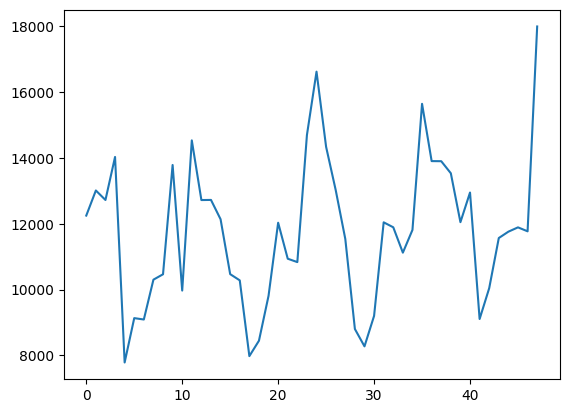

In [ ]:
data['SalesAmount'].plot()

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

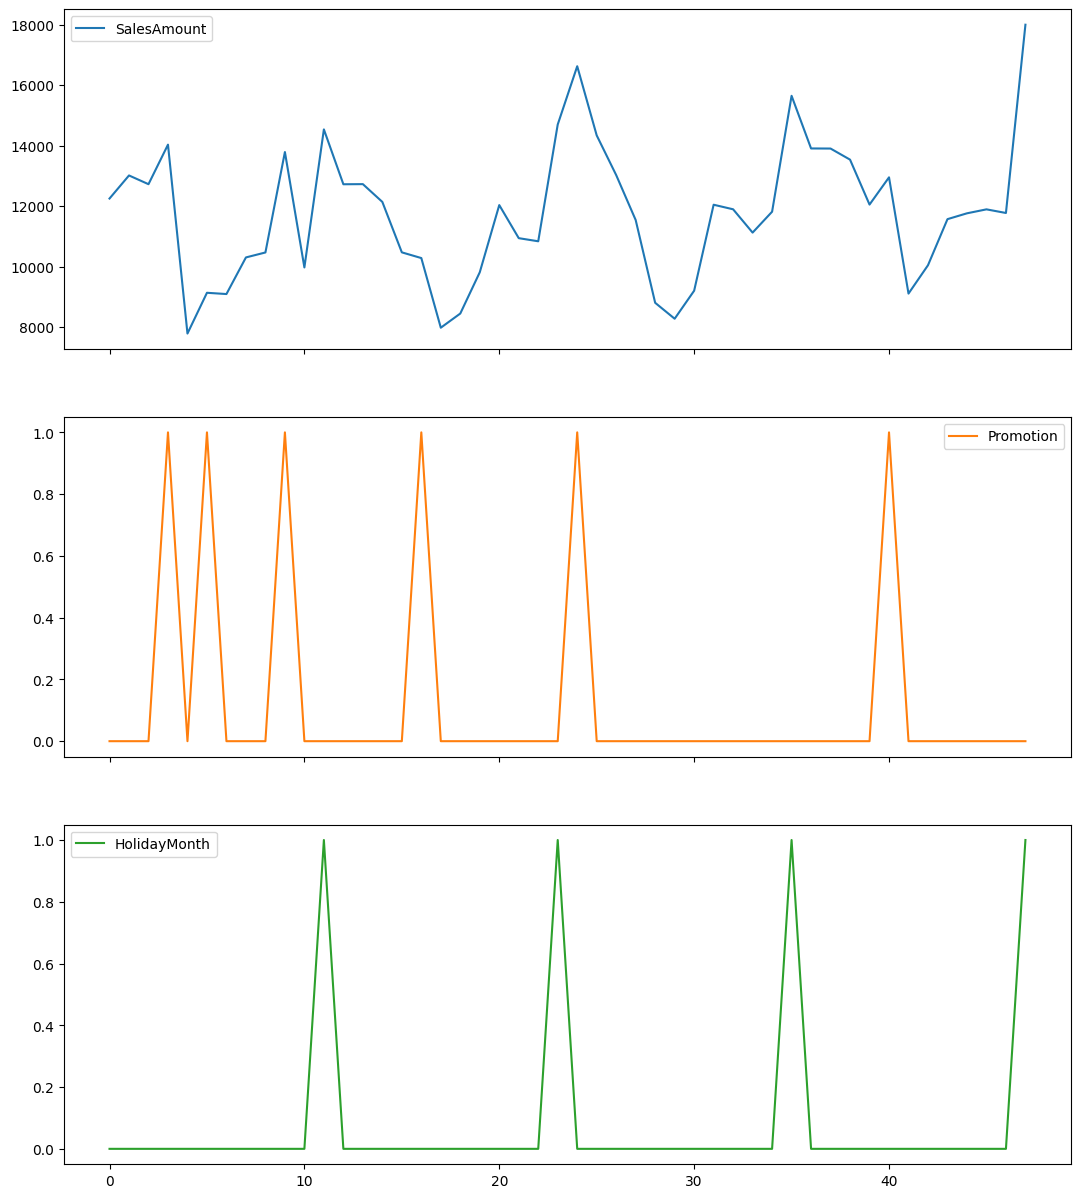

In [ ]:
data.plot(subplots=True, figsize=(13,15))

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

/tmp/ipykernel_12670/2273654071.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data.set_index('Date').resample('1Y').mean().plot(subplots = True)


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

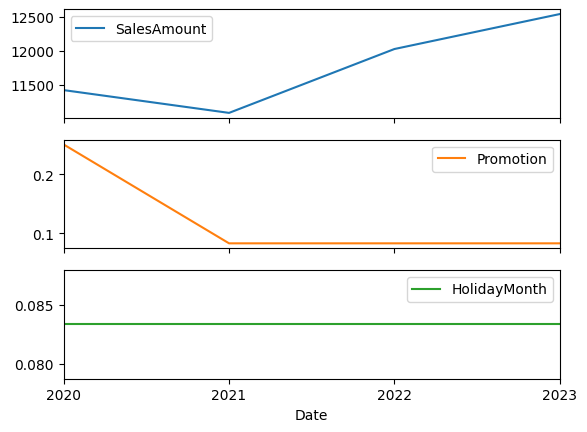

In [ ]:
data.set_index('Date').resample('1Y').mean().plot(subplots = True)

/tmp/ipykernel_12670/1159539848.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_year = data.set_index('Date').resample("1Y").mean()


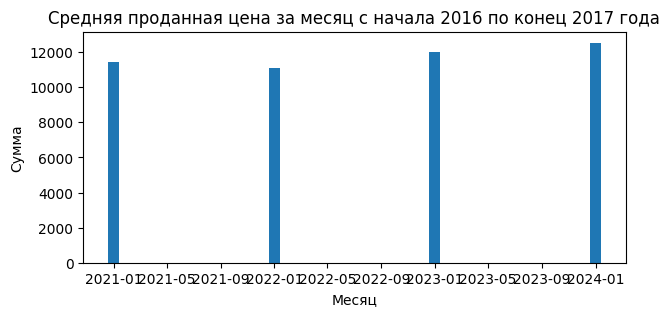

In [ ]:
# Группировка за месяц
#data_month = data.drop(columns=["Name"])

df_year = data.set_index('Date').resample("1Y").mean()
fig, ax = plt.subplots(figsize=(7, 3))
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
ax.bar(df_year['2019':].index, df_year.loc['2019':, "SalesAmount"], width=25, align='center')
ax.set(title = 'Средняя проданная цена за месяц с начала 2016 по конец 2017 года', xlabel = 'Месяц', ylabel = 'Сумма');

/tmp/ipykernel_12670/1541818768.py:4: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = data.set_index('Date').resample("1m").mean()


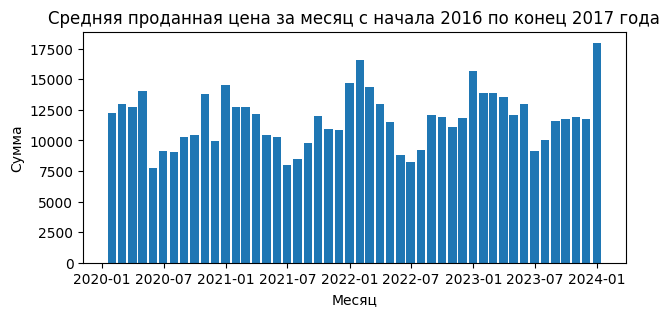

In [ ]:
# Группировка за месяц
#data_month = data.drop(columns=["Name"])

df_month = data.set_index('Date').resample("1m").mean()
fig, ax = plt.subplots(figsize=(7, 3))
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
ax.bar(df_month['2019':].index, df_month.loc['2019':, "SalesAmount"], width=25, align='center')
ax.set(title = 'Средняя проданная цена за месяц с начала 2016 по конец 2017 года', xlabel = 'Месяц', ylabel = 'Сумма');

<BarContainer object of 48 artists>

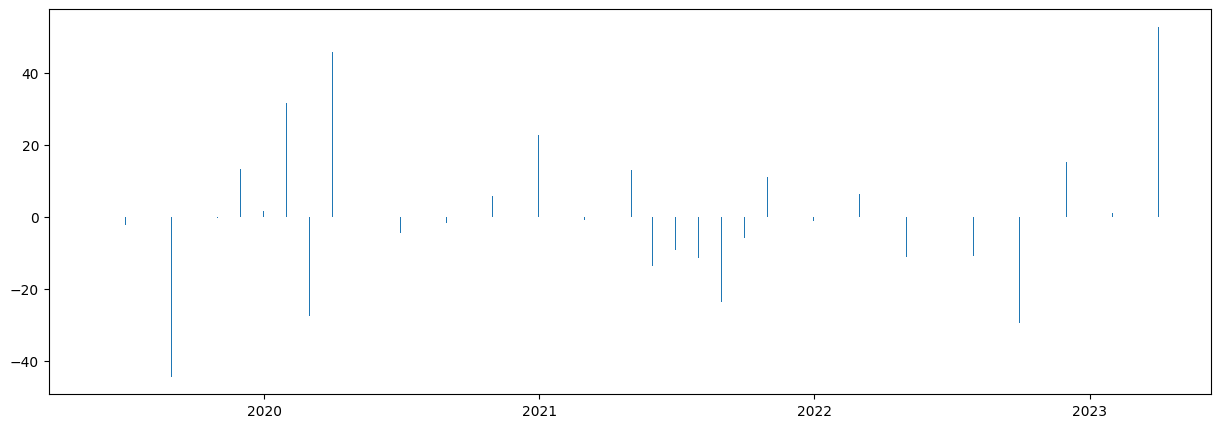

In [ ]:
import matplotlib.dates as mdates

df_month.loc[:, 'SalesAmount'] = df_month.SalesAmount.pct_change() * 100

fig, ax = plt.subplots(figsize=(15, 5))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.bar(df_month.index, df_month.loc[:, 'SalesAmount'])

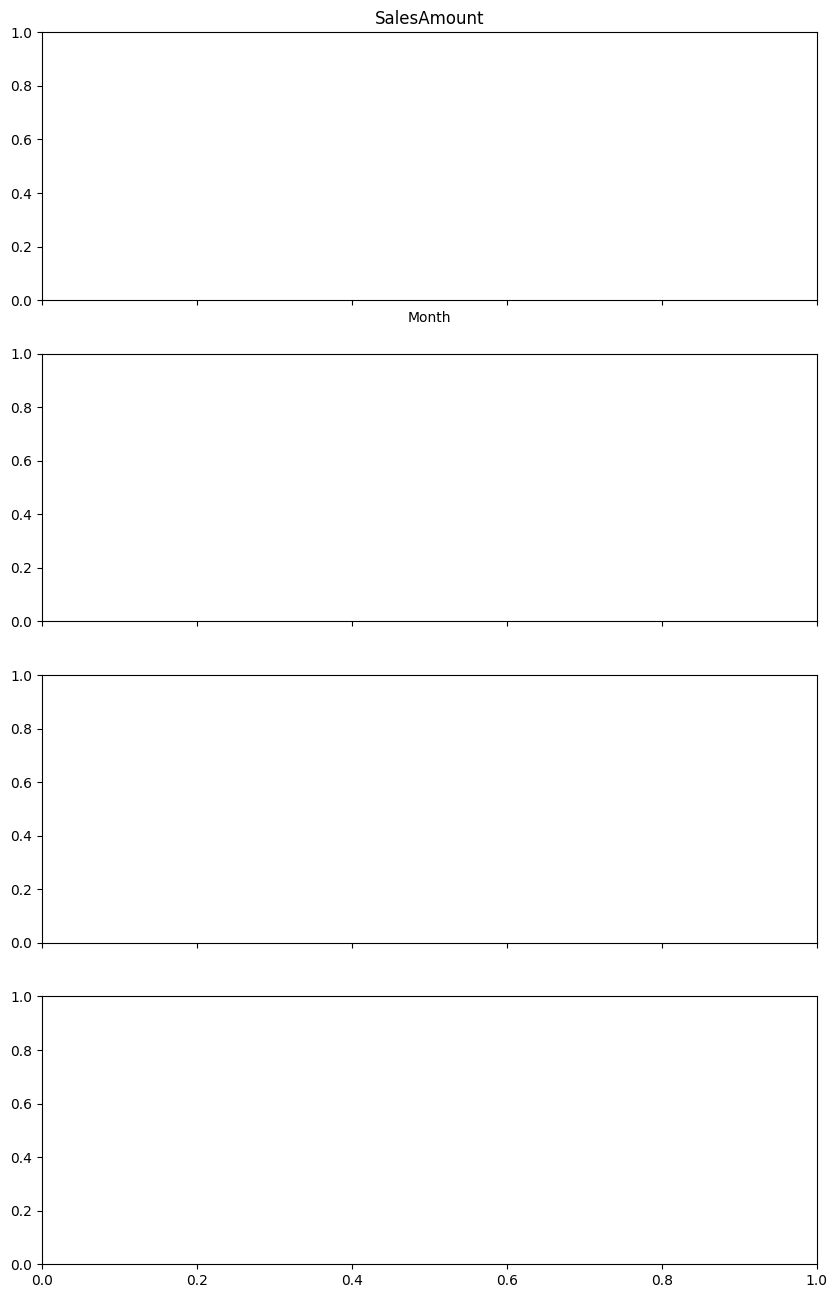

In [ ]:
import seaborn as sns

data['Month'] = data['Date'].dt.month
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)
for name, ax in zip(['SalesAmount'], axes):
  sns.boxplot(data=data[(data['Month'] >= 2019) & (data['Month'] <= 2024)], x='Month', y=name, ax=ax)
  ax.set_ylabel("") # чтобы избежать дублирования ax.set_title(name)
  ax.set_xlabel("Month")
  ax.set_title(name)

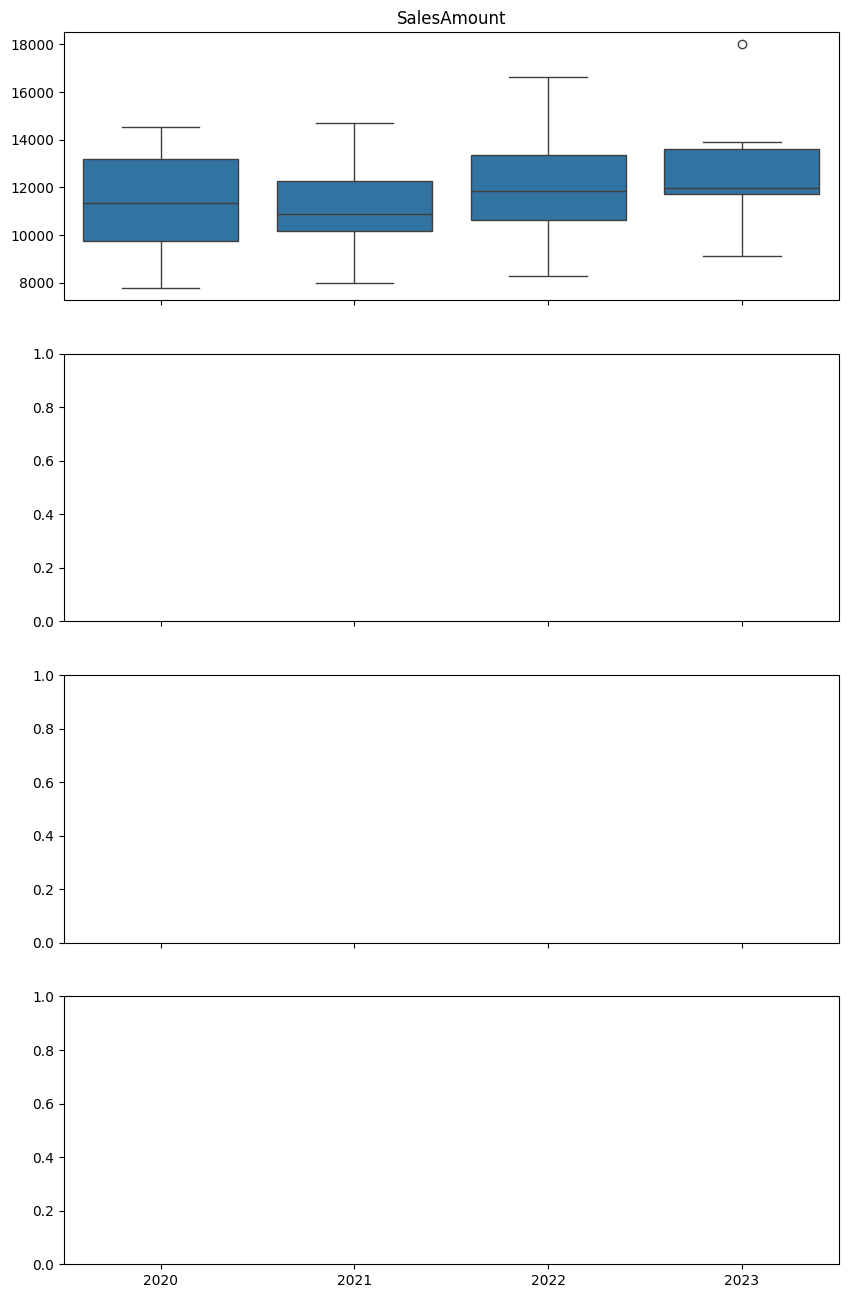

In [ ]:
import seaborn as sns

data['year'] = data['Date'].dt.year
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)
for name, ax in zip(['SalesAmount'], axes):
  sns.boxplot(data=data[(data['year'] >= 2019) & (data['year'] <= 2024)], x='year', y=name, ax=ax)
  ax.set_ylabel("") # чтобы избежать дублирования ax.set_title(name)
  ax.set_xlabel("year")
  ax.set_title(name)

,name,adf_stat,p_value,nobs
0,SalesAmount,-4.514184,0.000185,42
1,diff1,-5.629594,0.000001,36
2,diff12,-3.626089,0.005281,32
3,diff1+diff12,-4.669731,0.000096,29


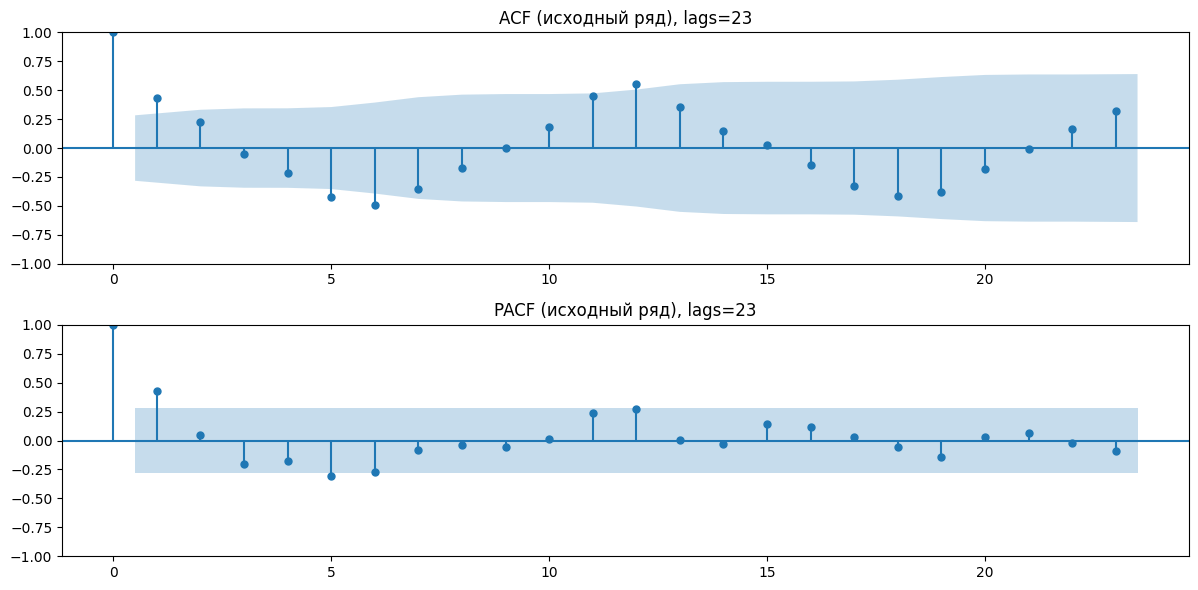

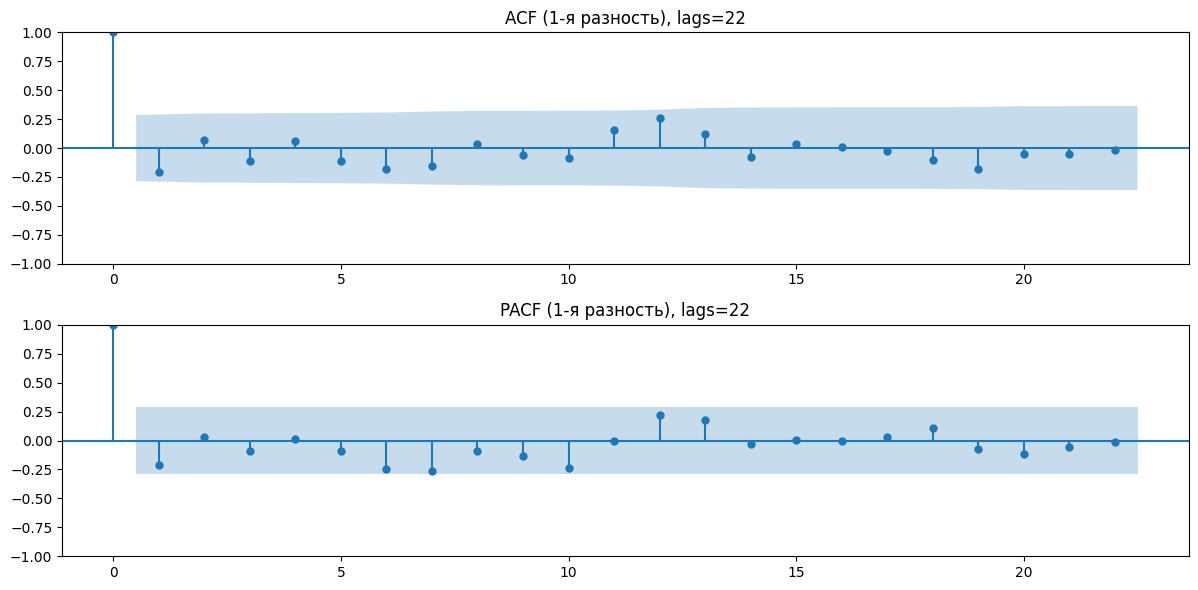

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = data["SalesAmount"].astype(float)
def adf_test(series, name="series"):
    s = pd.Series(series).dropna().astype(float)
    res = adfuller(s, autolag="AIC")
    return {
        "name": name,
        "adf_stat": res[0],
        "p_value": res[1],
        "nobs": res[3],
    }


def safe_nlags(series, target=24):
    s = pd.Series(series).dropna()
    # Ограничение statsmodels: nlags < n/2
    return int(min(target, max(1, (len(s) // 2) - 1)))

adf_df = pd.DataFrame([
    adf_test(y, "SalesAmount"),
    adf_test(y.diff(1), "diff1"),
    adf_test(y.diff(12), "diff12"),
    adf_test(y.diff(1).diff(12), "diff1+diff12"),
])
display(adf_df)

# Исходный ряд
lags0 = safe_nlags(y, target=24)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(y.dropna(), ax=ax[0], lags=lags0)
ax[0].set_title(f"ACF (исходный ряд), lags={lags0}")
plot_pacf(y.dropna(), ax=ax[1], lags=lags0, method="ywm")
ax[1].set_title(f"PACF (исходный ряд), lags={lags0}")
plt.tight_layout()
plt.show()

# 1-я разность
yd1 = y.diff(1).dropna()
lags1 = safe_nlags(yd1, target=24)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(yd1, ax=ax[0], lags=lags1)
ax[0].set_title(f"ACF (1-я разность), lags={lags1}")
plot_pacf(yd1, ax=ax[1], lags=lags1, method="ywm")
ax[1].set_title(f"PACF (1-я разность), lags={lags1}")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data['SalesAmount'], model='additive', period=10)


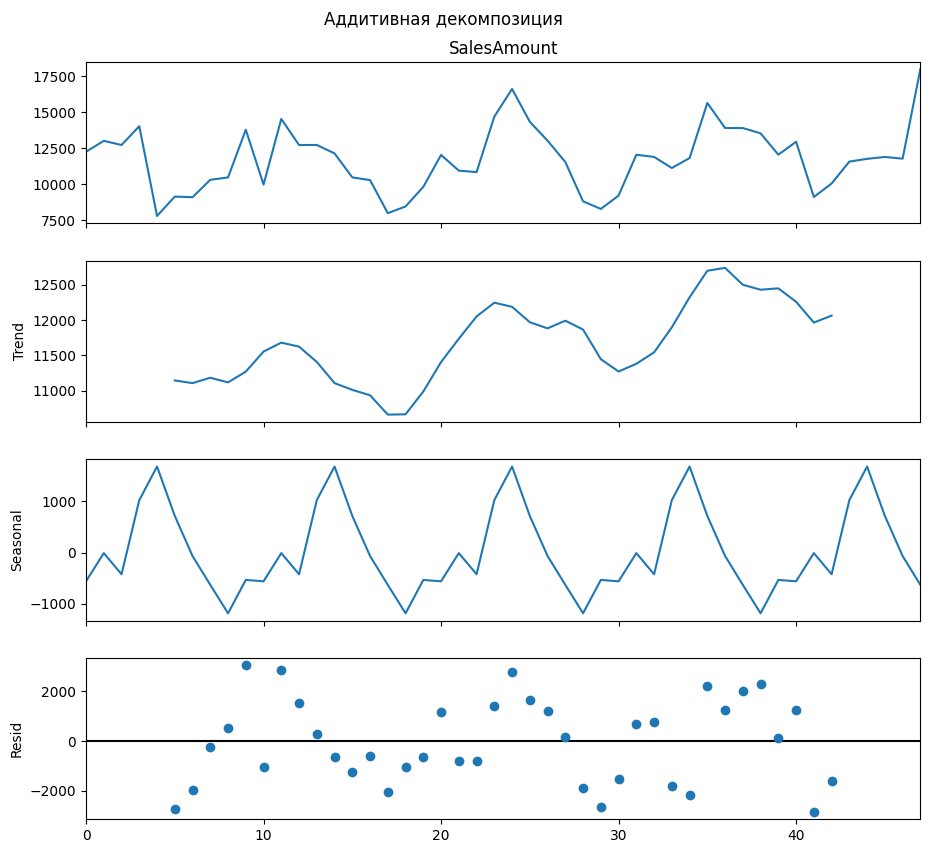

In [ ]:
fig2 = result.plot()
fig2.set_size_inches((10, 9))
plt.suptitle('Аддитивная декомпозиция')
plt.show()

In [ ]:
result_add = seasonal_decompose(data['SalesAmount'], model='multiplicative', period=10)

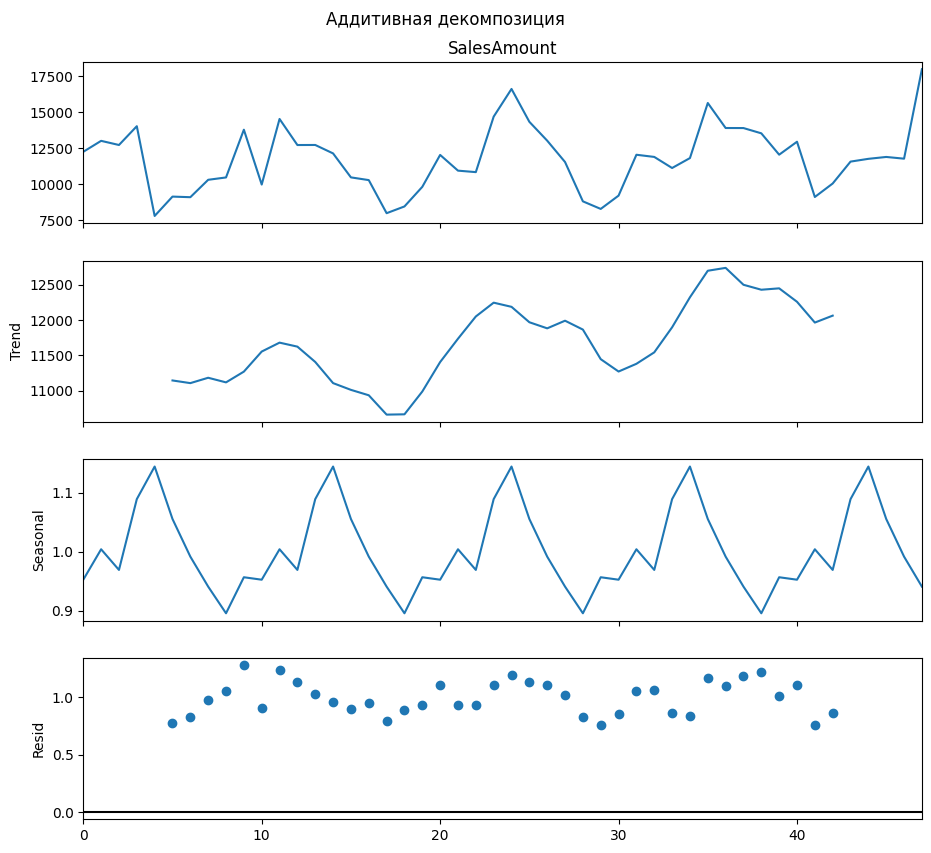

In [ ]:
fig = result_add.plot()
fig.set_size_inches((10, 9))
plt.suptitle('Аддитивная декомпозиция')
plt.show()


,period_months,amplitude
0,12.000000,58111.281744
1,4.000000,20169.892098
2,2.000000,16066.593139
3,6.000000,13752.887346
4,2.400000,12845.403788
5,2.086957,12415.917017
6,2.181818,12329.701205
7,3.692308,11271.122213
8,3.428571,10857.729778
9,3.000000,10848.769423


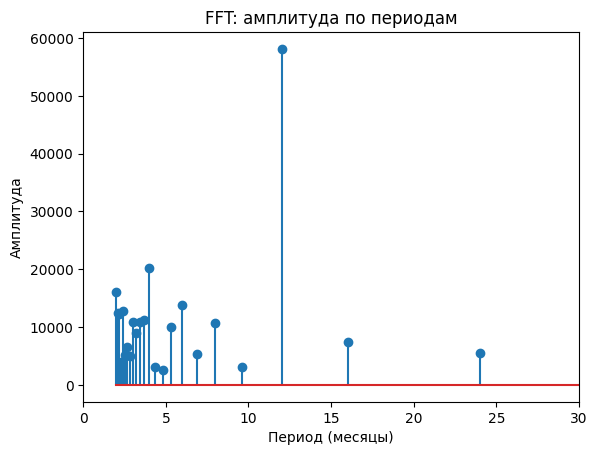

In [ ]:
from scipy import signal
import numpy as np

s_detr = signal.detrend(y.values.astype(float))

n = len(s_detr)
freqs = np.fft.rfftfreq(n, d=1.0)  # шаг = 1 месяц
fft_vals = np.fft.rfft(s_detr)
amp = np.abs(fft_vals)

mask = freqs > 0
freqs = freqs[mask]
amp = amp[mask]
periods = 1 / freqs

order = np.argsort(amp)[::-1]
top = pd.DataFrame({
    "period_months": periods[order][:10],
    "amplitude": amp[order][:10],
})
display(top)

plt.figure()
plt.stem(periods, amp)
plt.xlim(0, 30)
plt.title("FFT: амплитуда по периодам")
plt.xlabel("Период (месяцы)")
plt.ylabel("Амплитуда")
plt.show()

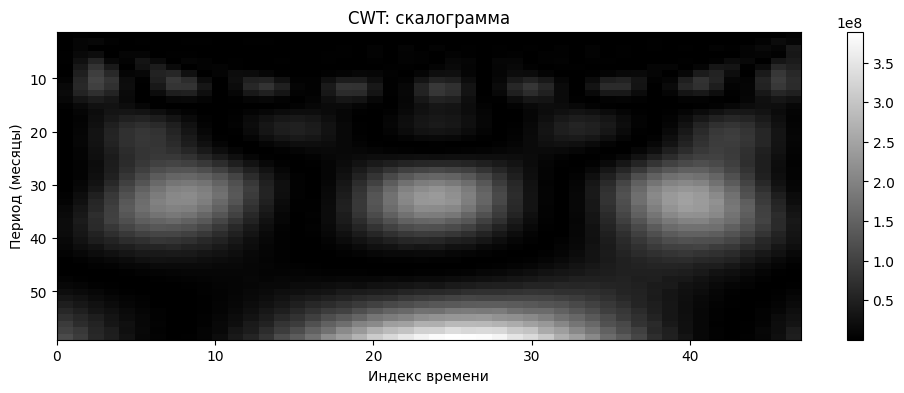

In [ ]:
# (3) Вейвлет-анализ (CWT, Morlet)
import pywt

s_vals = y.values.astype(float)
scales = np.arange(1, 49)
wavelet = "morl"

coeffs, _ = pywt.cwt(s_vals, scales=scales, wavelet=wavelet)
power = np.abs(coeffs) ** 2

pseudo_freq = pywt.scale2frequency(wavelet, scales)
pseudo_period = 1 / pseudo_freq

plt.figure(figsize=(12, 4))
extent = [0, len(y) - 1, pseudo_period.max(), pseudo_period.min()]
plt.imshow(power, extent=extent, aspect="auto", cmap="gray")
plt.title("CWT: скалограмма")
plt.xlabel("Индекс времени")
plt.ylabel("Период (месяцы)")
plt.colorbar()
plt.show()

In [ ]:
# Разделение на train/test
# При 48 точках разумно оставить последние 12 месяцев на тест.
exog = data[["Promotion", "HolidayMonth"]].astype(float)

test_size = 12
train_y, test_y = y.iloc[:-test_size], y.iloc[-test_size:]
train_exog, test_exog = exog.iloc[:-test_size], exog.iloc[-test_size:]

print("train:", len(train_y))
print("test :", len(test_y))

# Горизонт прогноза: максимально возможный на test
h = len(test_y)
assert h == test_size

train: 36
test : 12


In [ ]:
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

def fit_sarimax(
    endog,
    exog=None,
    order=(1, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    maxiter=300,
):
    model = SARIMAX(
        endog,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    # На коротких рядах часть комбинаций не сходится — это нормально.
    # Подавляем ConvergenceWarning и отбрасываем несошедшиеся модели.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        res = model.fit(disp=False, method="lbfgs", maxiter=maxiter)

    converged = bool(getattr(res, "mle_retvals", {}).get("converged", True))
    if not converged:
        raise ValueError("Модель не сошлась")
    return res


def grid_search_aic(
    endog,
    exog=None,
    p_range=(0, 1, 2),
    d_range=(0, 1),
    q_range=(0, 1, 2),
    P_range=(0, 1),
    D_range=(0, 1),
    Q_range=(0, 1),
    s=12,
    seasonal=True,
    trend="n",
    max_evals=200,
):
    rows = []
    evals = 0

    for (p, d, q) in product(p_range, d_range, q_range):
        if seasonal:
            for (P, D, Q) in product(P_range, D_range, Q_range):
                seasonal_order = (P, D, Q, s)
                try:
                    res = fit_sarimax(
                        endog,
                        exog=exog,
                        order=(p, d, q),
                        seasonal_order=seasonal_order,
                        trend=trend,
                    )
                except Exception:
                    continue

                rows.append({
                    "order": (p, d, q),
                    "seasonal_order": seasonal_order,
                    "aic": float(res.aic),
                    "bic": float(res.bic),
                })

                evals += 1
                if evals >= max_evals:
                    break
            if evals >= max_evals:
                break
        else:
            try:
                res = fit_sarimax(
                    endog,
                    exog=exog,
                    order=(p, d, q),
                    seasonal_order=(0, 0, 0, 0),
                    trend=trend,
                )
            except Exception:
                continue

            rows.append({
                "order": (p, d, q),
                "seasonal_order": (0, 0, 0, 0),
                "aic": float(res.aic),
                "bic": float(res.bic),
            })

            evals += 1
            if evals >= max_evals:
                break

    out = pd.DataFrame(rows)
    out = out.sort_values(["aic", "bic"], ascending=True).reset_index(drop=True)
    return out
arima_candidates = grid_search_aic(
    train_y,
    exog=None,
    p_range=(0, 1, 2, 3),
    d_range=(0, 1),
    q_range=(0, 1, 2, 3),
    seasonal=False,
    trend="n",
    max_evals=300,
)

display(arima_candidates.head(10))

best_arima_order = tuple(arima_candidates.loc[0, "order"])
print("Best ARIMA order:", best_arima_order)

arima_res = fit_sarimax(train_y, exog=None, order=best_arima_order, seasonal_order=(0, 0, 0, 0), trend="n")
print(arima_res.summary())

,order,seasonal_order,aic,bic
0,"(3, 1, 3)","(0, 0, 0, 0)",561.265196,571.303107
1,"(0, 1, 3)","(0, 0, 0, 0)",561.907967,567.643916
2,"(1, 1, 3)","(0, 0, 0, 0)",563.857219,571.027155
3,"(2, 1, 3)","(0, 0, 0, 0)",564.668133,573.272056
4,"(2, 0, 3)","(0, 0, 0, 0)",586.894995,595.689411
5,"(3, 1, 1)","(0, 0, 0, 0)",587.488802,594.817482
6,"(3, 1, 2)","(0, 0, 0, 0)",588.565922,597.360338
7,"(3, 0, 3)","(0, 0, 0, 0)",588.645260,598.905411
8,"(1, 0, 3)","(0, 0, 0, 0)",589.295559,596.624239
9,"(0, 1, 2)","(0, 0, 0, 0)",590.827155,595.224363


Best ARIMA order: (3, 1, 3)
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -273.633
Date:                Wed, 22 Apr 2026   AIC                            561.265
Time:                        18:59:14   BIC                            571.303
Sample:                             0   HQIC                           564.537
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0575      0.302     -3.499      0.000      -1.650      -0.465
ar.L2          0.2294      0.548      0.419      0.675      -0.844       1.303
ar.L3          0.4318   

In [ ]:
sarimax_candidates = grid_search_aic(
    train_y,
    exog=train_exog,
    p_range=(0, 1, 2),
    d_range=(0, 1),
    q_range=(0, 1, 2),
    P_range=(0, 1),
    D_range=(0, 1),
    Q_range=(0, 1),
    s=12,
    seasonal=True,
    trend="n",
    max_evals=300,
)

display(sarimax_candidates.head(10))

best_sarimax_order = tuple(sarimax_candidates.loc[0, "order"])
best_sarimax_seasonal = tuple(sarimax_candidates.loc[0, "seasonal_order"])
print("Best SARIMAX order:", best_sarimax_order)
print("Best SARIMAX seasonal_order:", best_sarimax_seasonal)

sarimax_res = fit_sarimax(train_y, exog=train_exog, order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="n")
print(sarimax_res.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

,order,seasonal_order,aic,bic
0,"(2, 1, 2)","(0, 1, 1, 12)",133.731265,134.366797
1,"(0, 1, 2)","(0, 1, 1, 12)",134.775303,135.251952
2,"(2, 1, 2)","(1, 1, 1, 12)",135.579404,136.294378
3,"(0, 1, 2)","(1, 1, 1, 12)",135.940753,136.496844
4,"(1, 1, 2)","(1, 1, 1, 12)",137.936501,138.572033
5,"(1, 1, 2)","(0, 1, 1, 12)",138.517729,139.073820
6,"(2, 1, 1)","(0, 1, 1, 12)",146.392994,147.773566
7,"(2, 1, 0)","(1, 1, 0, 12)",147.387811,148.571158
8,"(2, 1, 1)","(1, 1, 1, 12)",148.267929,149.845726
9,"(2, 1, 0)","(1, 1, 1, 12)",148.989129,150.369701


Best SARIMAX order: (2, 1, 2)
Best SARIMAX seasonal_order: (0, 1, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                      SARIMAX Results                                       
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 -58.866
Date:                              Wed, 22 Apr 2026   AIC                            133.731
Time:                                      19:00:12   BIC                            134.367
Sample:                                           0   HQIC                           129.445
                                               - 36                                         
Covariance Type:                                opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2583.2959   1926.049      1.341      0.180   -1191.691    6358.283
HolidayMonth 

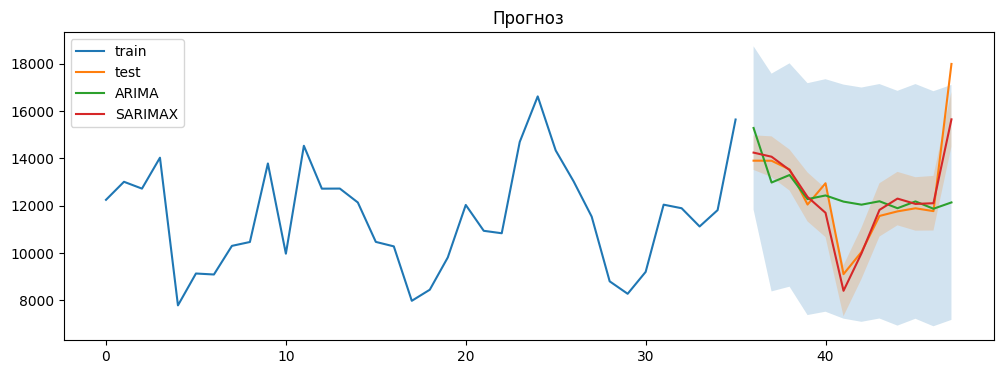

In [ ]:
# Прогноз на тест (12 месяцев)

arima_fc = arima_res.get_forecast(steps=h)
arima_mean = arima_fc.predicted_mean
arima_ci = arima_fc.conf_int(alpha=0.05)

sarimax_fc = sarimax_res.get_forecast(steps=h, exog=test_exog)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)

arima_mean.index = test_y.index
sarimax_mean.index = test_y.index

plt.figure(figsize=(12, 4))
plt.plot(train_y.index, train_y.values, label="train")
plt.plot(test_y.index, test_y.values, label="test")
plt.plot(test_y.index, arima_mean.values, label="ARIMA")
plt.plot(test_y.index, sarimax_mean.values, label="SARIMAX")

plt.fill_between(test_y.index, arima_ci.iloc[:, 0].values, arima_ci.iloc[:, 1].values, alpha=0.2)
plt.fill_between(test_y.index, sarimax_ci.iloc[:, 0].values, sarimax_ci.iloc[:, 1].values, alpha=0.2)

plt.title("Прогноз")
plt.legend()
plt.show()

Вывод: по подбору AIC получились модели:

ARIMA(3, 1, 3) (базовая, без факторов)
SARIMAX(2, 1, 2)×(0, 1, 1, 12) + Promotion, HolidayMonth (сезонная с факторами)
Далее сравнение делаем на тесте (12 месяцев) и по диагностике остатков.

,model,MSE,R2,AIC,BIC
1,"SARIMAX(2, 1, 2)x(0, 1, 1, 12) + exog",6.923379e+05,0.850301,133.731265,134.366797
0,"ARIMA(3, 1, 3)",4.280840e+06,0.074384,561.265196,571.303107


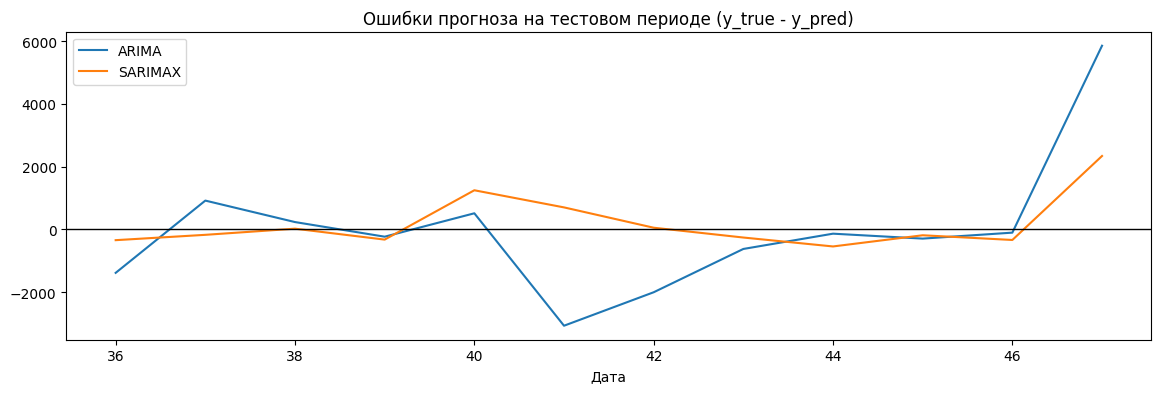

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def eval_forecast(y_true, y_pred, name, aic, bic):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    return {
        "model": name,
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "AIC": float(aic),
        "BIC": float(bic),
    }

arima_metrics = eval_forecast(
    test_y,
    arima_mean.values,
    name=f"ARIMA{best_arima_order}",
    aic=arima_res.aic,
    bic=arima_res.bic,
)

sarimax_metrics = eval_forecast(
    test_y,
    sarimax_mean.values,
    name=f"SARIMAX{best_sarimax_order}x{best_sarimax_seasonal} + exog",
    aic=sarimax_res.aic,
    bic=sarimax_res.bic,
)

metrics_df = pd.DataFrame([arima_metrics, sarimax_metrics]).sort_values("MSE")
display(metrics_df)

# Ошибка по времени
err = pd.DataFrame({
    "y_true": test_y.values,
    "ARIMA": test_y.values - arima_mean.values,
    "SARIMAX": test_y.values - sarimax_mean.values,
}, index=test_y.index)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
err[["ARIMA", "SARIMAX"]].plot(ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Ошибки прогноза на тестовом периоде (y_true - y_pred)")
ax.set_xlabel("Дата")
plt.show()

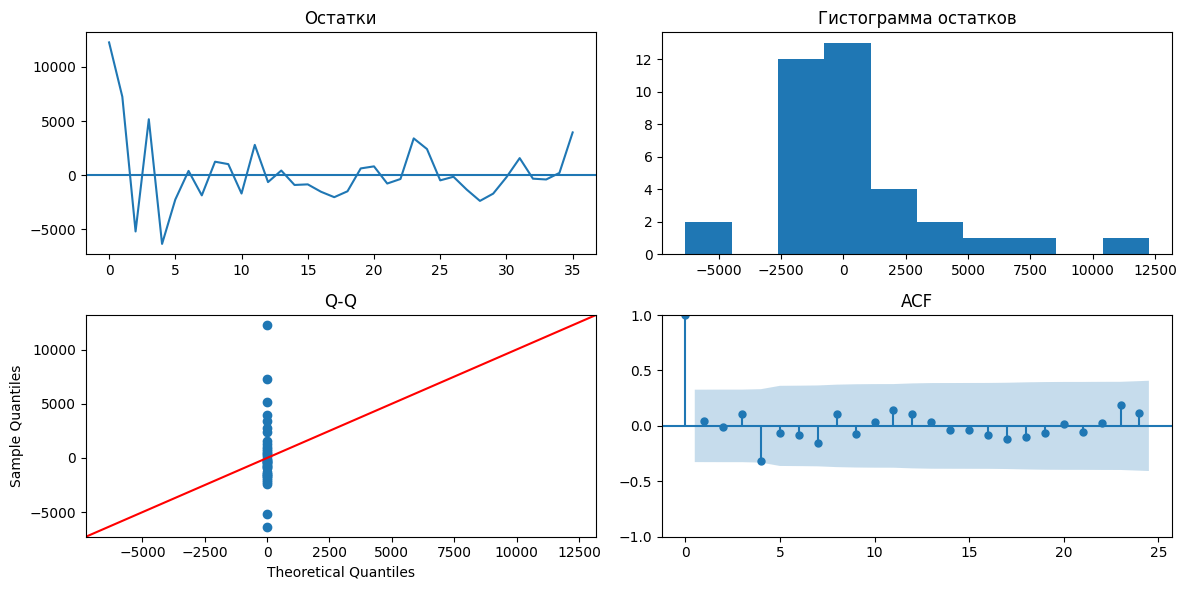

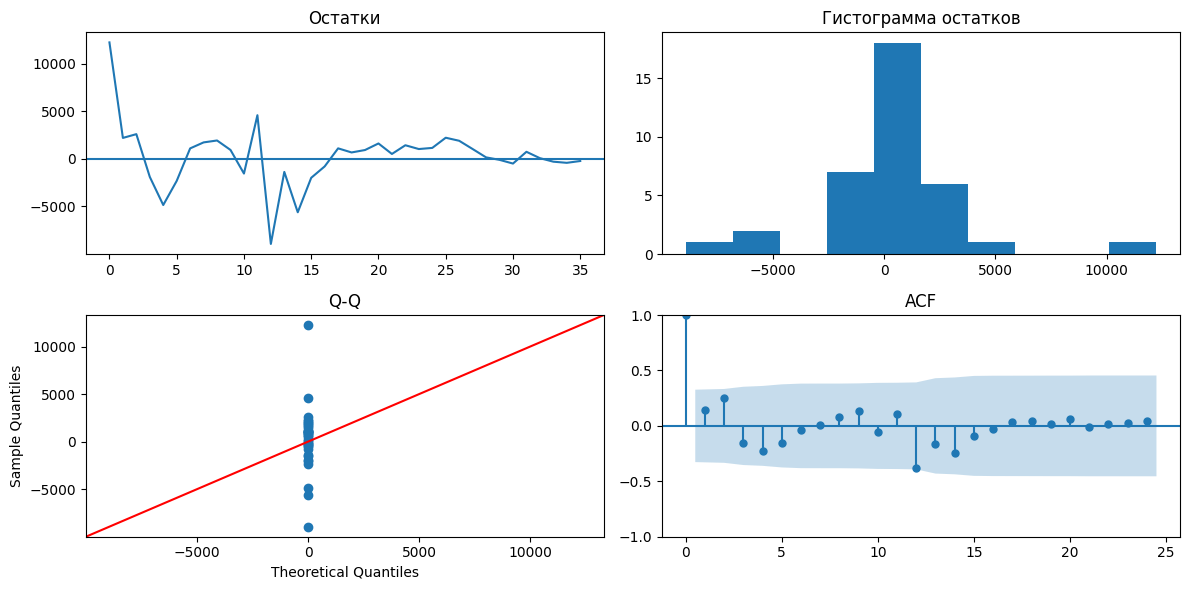

,model,JB_p,LjungBox_p(lag12),ARCH_p
0,ARIMA,3.089408e-08,0.686238,0.248285
1,SARIMAX,3.088887e-10,0.118660,0.872207


In [ ]:
# Диагностика остатков
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import statsmodels.api as sm


def residual_diagnostics(res, title):
    resid = pd.Series(res.resid).dropna().astype(float)

    _, jb_p, _, _ = jarque_bera(resid)
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    _, arch_p, _, _ = het_arch(resid)

    out = {
        "model": title,
        "JB_p": float(jb_p),
        "LjungBox_p(lag12)": float(lb["lb_pvalue"].iloc[0]),
        "ARCH_p": float(arch_p),
    }

    fig, ax = plt.subplots(2, 2, figsize=(12, 6))

    ax[0, 0].plot(resid.index, resid.values)
    ax[0, 0].axhline(0)
    ax[0, 0].set_title("Остатки")

    ax[0, 1].hist(resid.values, bins=10)
    ax[0, 1].set_title("Гистограмма остатков")

    sm.qqplot(resid, line="45", ax=ax[1, 0])
    ax[1, 0].set_title("Q-Q")

    plot_acf(resid, ax=ax[1, 1], lags=24)
    ax[1, 1].set_title("ACF")

    plt.tight_layout()
    plt.show()

    return out

arima_diag = residual_diagnostics(arima_res, "ARIMA")
sarimax_diag = residual_diagnostics(sarimax_res, "SARIMAX")

diag_df = pd.DataFrame([arima_diag, sarimax_diag])
display(diag_df)

По тесту (12 месяцев) SARIMAX лучше: MSE ≈ 6.92e5, R² ≈ 0.85 (у ARIMA: MSE ≈ 4.28e6, R² ≈ 0.07).
По AIC/BIC также лучше SARIMAX: AIC ≈ 133.73, BIC ≈ 134.37 (у ARIMA: AIC ≈ 561.27, BIC ≈ 571.30).
Остатки: автокорреляция по Ljung–Box не выявлена на лаге 12 (p≈0.69 у ARIMA, p≈0.12 у SARIMAX), ARCH-эффект незначим (p≈0.25 и p≈0.87).
Нормальность остатков по Jarque–Bera отвергается у обеих моделей (p≈3e-8 и p≈3e-10), т.е. остатки не нормальные.

По метрикам и критериям на тесте предпочтительна SARIMAX(2,1,2)×(0,1,1,12) + exog, т.к. она дала существенно меньшую ошибку и более высокий R².